In [4]:
# NC growth sim ver 0.2 alpha

# # # # # # # Introduction:

# - This program is intended to simulate absorption spectra of growing nanocrystals. The program works through a kinetic Monte Carlo technique,
#   in which an arbitrary number of steps are taken, each step carrying no weight in to the next step. At each step, a weighted die is rolled to
#   determine which one of a number of spheres (nucleation points) is awarded a piece of "monomer". Once a sphere covers its entire surface with
#   "monomer" pieces, its radius increases, and this changes its weight on the die according to some rate, k(r). The program saves samples of the
#   distribution at predetermined steps, then plots these distributions on a histogram of # of spheres/radius value. The program then converts units of
#   radius value to units of pseudojoules with the Brus Equation and the corresponding Jacobian factor (see https://pubs.acs.org/doi/10.1021/jz401508t).
#   We are then left with a histogram plot of # of spheres/energy value.


# - The next step is to convolve this histogram with the desired spectral lineshape, which results in the absorption spectra of nanocrystals at each
#   sampled point in "time". The convolution function works by performing a 1D convolution between a vector representing the spectral lineshape
#   and a vector representing the sphere counts at each energy value. It helped me to visualize this with the similar case of masks in computer vision
#   systems (see https://medium.com/analytics-vidhya/2d-convolution-using-python-numpy-43442ff5f381).

# # # # # # # Progress:

# - Added FWHM measurement

# # # # # # # Things I am working on currently:

# - Adding Arrhenius PDF

# - Adding variable nucleation sites


In [10]:
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy import constants
import random
import scipy.optimize as optimize
from datetime import datetime

In [11]:
# linear function
def linear_func(rng_array,sphere_radius):
    probability_array = 1/(np.array(sphere_surface_area))
    time_final = rng_array*probability_array
    return time_final

# Arrhenius rate - exponential radial probability dependence
def arrhenius_func(rng_array,sphere_radius,prexp,temp):
    probability_array = prexp*np.exp((-1*sphere_radius)/(scipy.R*temp))
    time_final = rng_array*probability_array
    return time_final

# rng engine
rng = np.random.default_rng()

In [22]:
# trial number
trial_number = 3

# number of spheres
number_of_spheres = 500

# defining initial sphere array - this is where the radial dependence of monomer probability comes from
sphere_radii = (np.ones(number_of_spheres))/100

# nucleation constants
nucleation_rate_constant = 1
nucleation_rate_order = 0
saturation_count = 1

# surface area - radius squared probability dependence
sphere_surface_area = 4*np.pi*(sphere_radii**2)
sphere_surface_area_counter = np.zeros(number_of_spheres)

# monomer size
monomer_area = 0.001
monomer_width = 0.001

# number of steps
steps = 1000001

# how many steps to sample
checkstep_amount = 20

# data vis
checksteps = []
colortable = []
for i in range(checkstep_amount):
    checksteps.append(np.round(((steps-1)*((i+1)/checkstep_amount))))
hist_array = []
sample_dists = []
checksteps_spheres = []
normal_array = 0

50000
08:15:54.972376
100000
08:15:56.683076
150000
08:15:58.188114
200000
08:15:59.580863
250000
08:16:00.834416
300000
08:16:02.135674
350000
08:16:03.407492
400000
08:16:04.863085
450000
08:16:06.283518
500000
08:16:07.574720
550000
08:16:09.024530
600000
08:16:10.274636
650000
08:16:11.658944
700000
08:16:13.144873
750000
08:16:14.479970
800000
08:16:15.812631
850000
08:16:17.108225
900000
08:16:18.480865
950000
08:16:19.783168
1000000
08:16:21.452572


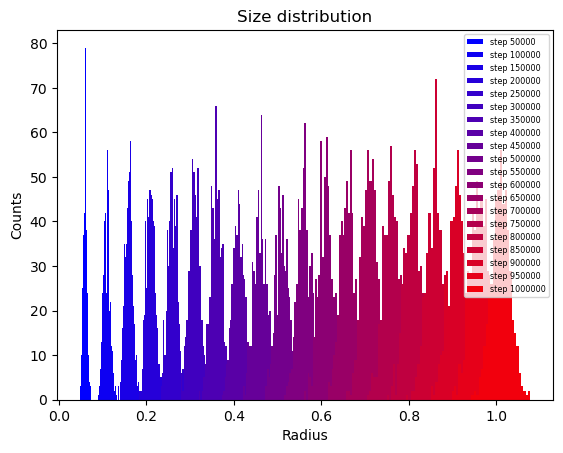

In [23]:
# kMC - linear probability distribution
for i in range(int(steps)):
    
    # find winner
    rng_array = rng.random(number_of_spheres)
    time_final = linear_func(rng_array,sphere_radii)
    growth_func = 'linear'
    winning_index = np.argmin(time_final)

    # find loser
    rng_array_loss = rng.random(number_of_spheres)
    time_final_loss = linear_func(rng_array_loss,sphere_radii)
    shrink_func = 'linear'
    losing_index = np.argmax(time_final)
    
    # award winner with monomer, promote if surface is covered
    sphere_surface_area_counter[winning_index] = sphere_surface_area_counter[winning_index]+monomer_area
    if sphere_surface_area_counter[winning_index] >= sphere_surface_area[winning_index]:
        sphere_radii[winning_index] = sphere_radii[winning_index]+monomer_width
        sphere_surface_area_counter[winning_index] = 0

    # remove monomer from loser, subtract layer if surface is empty
    if i > (steps/1): # this allows for a 'pure growth' phase, where monomer removal is not allowed
        if (i % 10 == 0): # this allows for control of removal speed
            sphere_surface_area_counter[losing_index] = sphere_surface_area_counter[losing_index]-monomer_area
            if sphere_surface_area_counter[losing_index] <= 0:
                if (sphere_radii[losing_index]-monomer_width >=0):
                    sphere_radii[losing_index] = sphere_radii[losing_index]-monomer_width
                    sphere_surface_area_counter[losing_index] = 0

    # nucleation rng
    nucleation_rng = rng.random(1)
    if (1-((number_of_spheres**nucleation_rate_order)/saturation_count)>nucleation_rng):
        number_of_spheres = number_of_spheres+(nucleation_rate_constant**nucleation_rate_order)
        for i9 in range(nucleation_rate_constant**nucleation_rate_order):
            sphere_radii = np.append(sphere_radii,0.001)
            sphere_surface_area = np.append(sphere_surface_area,4*np.pi)
            sphere_surface_area_counter = np.append(sphere_surface_area_counter,0)
    
    # save samples
    if i in checksteps:
        n,bins,patches = plt.hist(sphere_radii,bins=int(25),
                                  color=((1/len(checksteps))*int(checksteps.index(i)),0,1-(1/len(checksteps))*int(checksteps.index(i))),label='step '+str(i))
        checksteps_spheres.append(number_of_spheres)
        for index in range (len(sphere_radii)):
            sample_dists.append(sphere_radii[index])
            
    # live progress
    if i in checksteps:
        print(i)
        datetime = datetime.now()
        print(datetime.time())

# plot
plt.legend(fontsize='xx-small',loc='upper right')
plt.xlabel('Radius')
plt.ylabel('Counts')
plt.title('Size distribution')
plt.savefig(str(trial_number)+'NCgrowthsim_sizedist_.png',bbox_inches='tight',pad_inches=1)

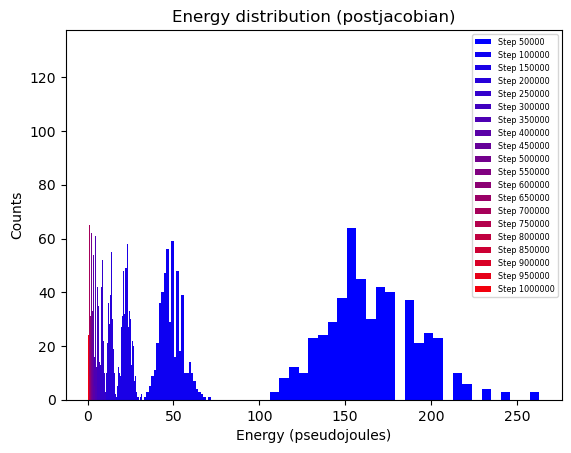

In [24]:
bin_edges_full = []
counts_full = []

# normalize
sample_dists_normalized = np.divide(sample_dists,max(sample_dists))

for i2 in range (len(checksteps)):
    postjacobian_dist_list = []
    for i in range (checksteps_spheres[i2]):
    # converts to (pseudo)joules, applies jacobian
        postjacobian_num = (2.8*(10**-19))+((1/(sample_dists_normalized
                                                [i+(checksteps_spheres[i2]*(i2))]**2))*(5.989*(10**-37))*(8.348*(10**35)))
        # fix this dependance on number_of_spheres
        postjacobian_dist_list.append(postjacobian_num)
   # bins_approx = np.sqrt(np.round(max(postjacobian_dist_list)-min(postjacobian_dist_list),decimals=0))
    counts,bin_edges,patches = plt.hist(postjacobian_dist_list,bins=int(np.round(len(checksteps)*1.4)-i2),
                                        color=((1/len(checksteps))*i2,0,1-(1/len(checksteps))*i2,1),
    label='Step '+str(int(checksteps[i2])))
    bin_edges_full.append(bin_edges)
    counts_full.append(counts)


plt.legend(fontsize='xx-small',loc='upper right')
plt.ylabel('Counts')
plt.xlabel('Energy (pseudojoules)')
plt.title('Energy distribution (postjacobian)')
plt.savefig(str(trial_number)+'NCgrowthsim_Edist_.png',bbox_inches='tight',pad_inches=1)

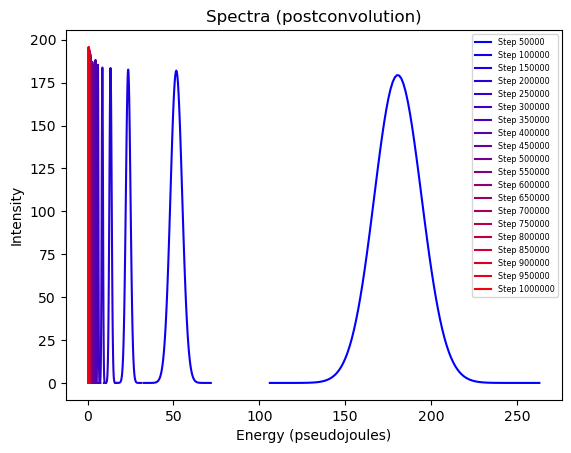

In [25]:
# lineshape definition - gaussian
def gaussian_function(xarr,center,sigma):
    return [(1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((x-center)/sigma)**2)))) for x in xarr]

def fit_gaussian_func(xarr,yarr):
    params,covariance = optimize.curve_fit(gaussian_function,xarr,yarr)
    return params

xarr1 = np.linspace(-5,5,100)
sigma = 1
center = 0
yarr1 = (1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((xarr1-center)/sigma)**2))))

# fwhm function
def fwhm_get(yarr):
    halfmax = 0.5*(np.argmax(yarr))
    fwhm = np.argmin(np.abs(yarr[:np.argmax(yarr)]-halfmax))-np.argmin(np.abs(yarr[np.argmax(yarr):]-halfmax))
    return fwhm

fwhm_arr = []

# get fwhm for each peak
for i in range(len(checksteps)):
    plt.plot(np.linspace(list(bin_edges_full[i])[0],list(bin_edges_full[i])[-1],len(np.convolve(counts_full[i][:-1],yarr1)))
             ,np.convolve(counts_full[i][:-1],yarr1),color=((1/len(checksteps))*i,0,1-(1/len(checksteps))*i,1),
    label='Step '+str(int(checksteps[i])))
    fwhm_arr.append(fwhm_get(np.convolve(counts_full[i][:-1],yarr1)))
    

plt.xlabel('Energy (pseudojoules)')
plt.ylabel('Intensity')
plt.title('Spectra (postconvolution)')
plt.legend(fontsize = 'xx-small',loc='upper right')
plt.savefig(str(trial_number)+'NCgrowthsim_convolvedspec_.png',bbox_inches='tight',pad_inches=1)

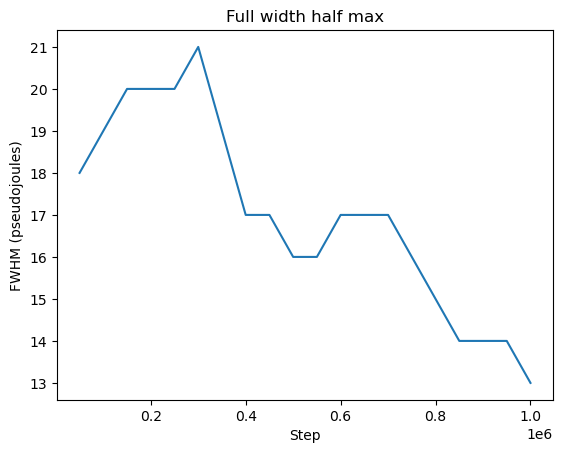

In [26]:
plt.plot(checksteps,fwhm_arr)
plt.xlabel('Step')
plt.ylabel('FWHM (pseudojoules)')
plt.title('Full width half max')
plt.savefig(str(trial_number)+'NCgrowthsim_FWHM_.png',bbox_inches='tight',pad_inches=1)

In [27]:
with open('trial'+str(trial_number)+'params', 'w') as file:
    file.write('Trial number: '+str(trial_number)+'\n'+'Steps:'+str(steps)+'\n'+'Number of spheres: '
               +str(number_of_spheres)+'\n'+'Monomer area: '+str(monomer_area)+'\n'+'Monomer width: '
               +str(monomer_width)+'\n'+'Growth function: '+str(growth_func)+'\n'+'Shrink function: '
               +str(shrink_func)+'\n'+'Saturation point: '+str(saturation_count))

In [ ]:
# ...
# ...

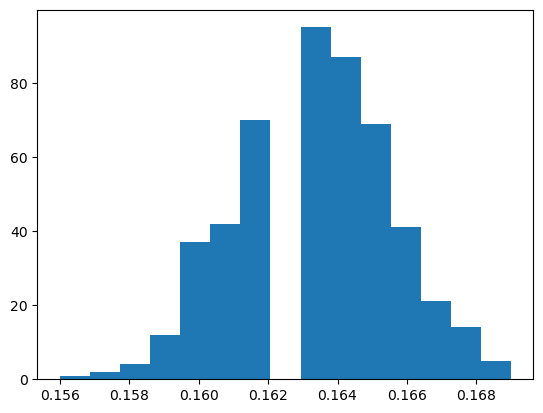

In [165]:
# this stuff is all junk


# get histogram data points
counts,bin_edges,patches = plt.hist(sphere_radii,bins=15)
step_center = []
for idx in range(np.size(bin_edges)-1):
    step_center.append((bin_edges[idx]+bin_edges[idx+1])/2)

        # step_center = []
        # for idx in range(np.size(bin_edges)-1):
        #    step_center.append((bin_edges[idx]+bin_edges[idx+1])/2)
        
        # least squares fit
        #center_guess = bin_edges[np.argmax(counts)]
        #center,sigma, = fit_gaussian_func(bin_edges[:-1],counts,center_guess,1)
        #xarr1 = np.linspace(0,2*(bin_edges[-1]+sigma),10000)
        #fitted_gaussian = (1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((xarr1-center)/sigma)**2))))

        # least squares fitting
        #plt.plot(xarr1,fitted_gaussian,color='blue')

# least squares fit
# center_guess = bin_edges[np.argmax(counts)]
# center,sigma = fit_gaussian_func(bin_edges[:-1],counts,center_guess,1)
# xarr1 = np.linspace(bin_edges[0]-sigma,bin_edges[-1]+sigma,100)
# fitted_gaussian = (1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((xarr1-center)/sigma)**2))))

Text(0, 0.5, 'Counts')

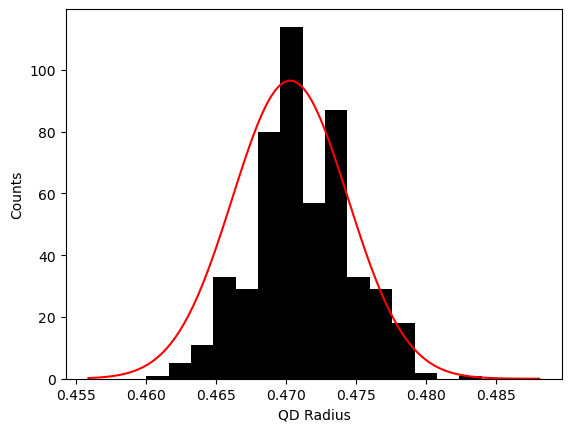

In [132]:
# plot histogram and least squares fitting
plt.plot(xarr1,fitted_gaussian,color='red')
plt.hist(sphere_radii,bins=15,color='black')
plt.xlabel('QD Radius')
plt.ylabel('Counts')

In [31]:
gaussian_xarr = np.linspace(-10,10,1000).reshape(1000,-1)
gaussian_yarr = np.array(gaussian_function(newarr,1,1)).reshape(1000,-1)
original_vector_array = np.hstack((gaussian_xarr,gaussian_yarr))

In [ ]:
# lineshape definition - gaussian
def gaussian_function(xarr,center,sigma):
    return [(1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((x-center)/sigma)**2)))) for x in xarr]

def fit_gaussian_func(xarr,yarr):
    params,covariance = optimize.curve_fit(gaussian_function,xarr,yarr)
    return params

xarr1 = np.linspace(0,100,1000)
sigma = 5
center = 0
yarr1 = (1/(sigma*(np.sqrt(2*np.pi)))*(np.e**((-1/2)*(((xarr1-center)/sigma)**2))))

# making an array for each histogram peak
half_bin_size = (list(bin_edges_full[1])[2]-list(bin_edges_full[1])[1])/2
bins_center_point = []

# convolution setup

counts_1 = counts_full[0]
counts_2 = counts_full[1]
counts_3 = counts_full[2]
counts_4 = counts_full[3]

# convolution
convolved_yfunc = []
xdomain = []

for i in range(len(checkpoints)):
    plt.plot(np.linspace(list(bin_edges_full[i])[0],list(bin_edges_full[i])[-1],len(np.convolve(counts_full[i][:-1],yarr1)))
             ,np.convolve(counts_full[i][:-1],yarr1),((1/len(checksteps))*i,0,1-(1/len(checksteps))*i,1),
    label='Step '+str(int(checksteps[i])))

convolved_yfunc_1 = np.convolve(counts_1[:-1],yarr1)
convolved_yfunc_2 = np.convolve(counts_2[:-1],yarr1)
convolved_yfunc_3 = np.convolve(counts_3[:-1],yarr1)
convolved_yfunc_4 = np.convolve(counts_4[:-1],yarr1)

xdomain_1 = np.linspace(list(bin_edges_full[0])[0],list(bin_edges_full[0])[-1],len(convolved_yfunc_1))
xdomain_2 = np.linspace(list(bin_edges_full[1])[0],list(bin_edges_full[1])[-1],len(convolved_yfunc_2))
xdomain_3 = np.linspace(list(bin_edges_full[2])[0],list(bin_edges_full[2])[-1],len(convolved_yfunc_3))
xdomain_4 = np.linspace(list(bin_edges_full[3])[0],list(bin_edges_full[3])[-1],len(convolved_yfunc_4))

# plot

plt.plot(xdomain_1,convolved_yfunc_1,color='red',label='Step 250000')
plt.plot(xdomain_2,convolved_yfunc_2,color='yellow',label='Step 500000')
plt.plot(xdomain_3,convolved_yfunc_3,color='green',label='Step 750000')
plt.plot(xdomain_4,convolved_yfunc_4,color='blue',label='Step 1000000')

plt.xlabel('Energy (pseudojoules)')
plt.ylabel('Intensity')
plt.legend()
plt.savefig('NCgrowthsim_convolvedspec_1.png',bbox_inches='tight',pad_inches=1)